# Recipe Clustering V11 – Bayesian Threshold Optimization

**Goal:** Find the optimal threshold exponent α that maximizes cluster membership
similarity to the hand-drawn reference image.

**Model base:** `as is × Grandfamilien` (OT1 only) — the best-performing model from V9.

**What we tune:**
```
ingredient contribution = Totalmenge × (1 / threshold_ppm)^α
```
- α = 0.0  →  Model-2 (no threshold, current best score 1.956)
- α = 1.0  →  Model-4 (full threshold, score 1.223)
- α ∈ [-0.5, 2.0]  →  search space for Bayesian optimization

**Objective:** Maximise total Jaccard similarity across 5 reference cluster groups.

## Setup

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

try:
    import faiss
    print('FAISS available')
except ImportError:
    raise RuntimeError('FAISS required')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print(f'Optuna {optuna.__version__} ready ✓')

FAISS available
Optuna 4.4.0 ready ✓


## 1. Load & Preprocess

In [2]:
DATA_PATH   = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH = '../data/gold/ignone_substances.csv'
CAS_PATH    = '../data/gold/CAS Nummern.csv'
OUTPUT_DIR  = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

ign_cas = ign[['Ident']].merge(
    cas[['Ident.','CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.':'Ident'}),
    on='Ident', how='left')
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0
per = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per > 0, df['Totalmenge'] / per, df['Totalmenge'])
assert df.groupby('Rez.-Nr.')['Totalmenge'].sum().round(6).eq(1.0).all()

recipes       = df['Rez.-Nr.'].unique().tolist()
OT1           = 'Odour Type 1 FlavourWheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'
print(f'Recipes: {len(recipes)},  active rows: {(df["Totalmenge"]>0).sum()}')

Recipes: 24,  active rows: 602


## 2. Core Functions

In [3]:
def norm_term(term):
    if pd.isna(term) or not isinstance(term, str): return None
    t = term.lower().strip().replace('"','').replace("'",'').rstrip('.,;:')
    return t if len(t) >= 2 else None

# Pre-resolve threshold values once (avoids repeated string parsing)
def resolve_thresholds(df):
    """Return series of numeric threshold values (NaN where missing/invalid)."""
    def parse(v):
        try:
            t = float(str(v).strip().replace(',','.'))
            return t if t > 0 else np.nan
        except:
            return np.nan
    return df[THRESHOLD_COL].map(parse)

df['_thresh'] = resolve_thresholds(df)
MEDIAN_THRESH = df.loc[df['_thresh'].notna(), '_thresh'].median()
print(f'Threshold stats: median={MEDIAN_THRESH:.4f} ppm,  '
      f'missing={df["_thresh"].isna().sum()} rows → fallback=median')

# Build vocabulary once
VOCAB = sorted({norm_term(v) for v in df[OT1].dropna() if norm_term(v)})
VI    = {t: i for i, t in enumerate(VOCAB)}
print(f'OT1 vocabulary ({len(VOCAB)} terms): {VOCAB}')

# Pre-compute per-row data needed for vector building
active = df[df['Totalmenge'] > 0].copy()
active['_ot1']  = active[OT1].map(norm_term)
active['_qty']  = active['Totalmenge']
# fill missing threshold with median
active['_thresh_filled'] = active['_thresh'].fillna(MEDIAN_THRESH)

# Recipe index
rec_idx = {r: i for i, r in enumerate(recipes)}

print('Pre-computation done ✓')

Threshold stats: median=0.5000 ppm,  missing=54 rows → fallback=median
OT1 vocabulary (9 terms): ['dairy', 'floral', 'fresh', 'fruity', 'green', 'odorless', 'unpleasant', 'warm', 'woody']
Pre-computation done ✓


In [4]:
def build_vectors(alpha):
    """
    Build L2-normalised recipe vectors with threshold exponent alpha.
    contribution = Totalmenge * (1/threshold)^alpha
    alpha=0  → no threshold (Model-2)
    alpha=1  → full threshold (Model-4)
    """
    vecs = np.zeros((len(recipes), len(VOCAB)), dtype=np.float64)
    for _, row in active.iterrows():
        term = row['_ot1']
        if not term or term not in VI:
            continue
        r_idx = rec_idx.get(row['Rez.-Nr.'])
        if r_idx is None:
            continue
        tf = (1.0 / row['_thresh_filled']) ** alpha
        vecs[r_idx, VI[term]] += row['_qty'] * tf
    return normalize(vecs)


def cluster_vectors(vecs, k_range=(3, 8)):
    """FAISS k-means, auto-select k by silhouette."""
    xf = np.ascontiguousarray(vecs.astype('float32'))
    best_k, best_s, best_lbl = k_range[0], -1, None
    for k in range(k_range[0], min(k_range[1]+1, len(recipes))):
        km = faiss.Kmeans(xf.shape[1], k, niter=50, verbose=False, seed=42)
        km.train(xf)
        _, lbl = km.index.search(xf, 1)
        lbl = lbl.flatten()
        if len(set(lbl)) > 1:
            s = silhouette_score(xf, lbl)
            if s > best_s:
                best_s, best_k, best_lbl = s, k, lbl.copy()
    return best_lbl, best_k, best_s


# Reference clusters from the hand-drawn image
REFERENCE = {
    'Karamell'    : {'186.277P','187.800P','187.916P','185.237H','188.740P'},
    'Grün'        : {'185.091','185.309P','188.412P','185.090P','187.657P','185.675P'},
    'Walderdbeer' : {'187.796P','185.267','185.471','185.382P','187.886P','187.507P','187.894P','186.190P'},
    'Isolated'    : {'185.028'},
    'Transitional': {'187.694P','185.507P','185.294','187.787P'},
}

def jaccard_score(labels):
    """Total Jaccard similarity between predicted clusters and reference."""
    clusters = {}
    for l in set(labels):
        clusters[l] = {r for r, lb in zip(recipes, labels) if lb == l}
    total = 0.0
    for ref_set in REFERENCE.values():
        best = 0.0
        for cset in clusters.values():
            shared = ref_set & cset
            union  = ref_set | cset
            best   = max(best, len(shared)/len(union) if union else 0)
        total += best
    return total


# Verify baseline
vecs_base = build_vectors(alpha=0.0)
lbl_base, k_base, s_base = cluster_vectors(vecs_base)
score_base = jaccard_score(lbl_base)
print(f'Baseline α=0.0 (Model-2): k={k_base}, silhouette={s_base:.4f}, Jaccard={score_base:.3f}')

vecs_m4 = build_vectors(alpha=1.0)
lbl_m4, k_m4, s_m4 = cluster_vectors(vecs_m4)
score_m4 = jaccard_score(lbl_m4)
print(f'Baseline α=1.0 (Model-4): k={k_m4}, silhouette={s_m4:.4f}, Jaccard={score_m4:.3f}')

Baseline α=0.0 (Model-2): k=3, silhouette=0.2893, Jaccard=1.956
Baseline α=1.0 (Model-4): k=4, silhouette=0.3829, Jaccard=1.223


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24

## 3. Brute-Force Scan First

Before Bayesian optimization, scan α at fine resolution to see the full landscape.
This also reveals whether the objective is smooth or has many local optima.

In [5]:
alphas    = np.linspace(-0.5, 2.0, 101)
jaccards  = []
silhous   = []
ks        = []

for a in alphas:
    vecs      = build_vectors(alpha=a)
    lbl, k, s = cluster_vectors(vecs)
    j         = jaccard_score(lbl)
    jaccards.append(j)
    silhous.append(s)
    ks.append(k)

best_idx   = int(np.argmax(jaccards))
best_alpha = float(alphas[best_idx])
best_j     = jaccards[best_idx]

print(f'Scan best  α={best_alpha:.3f}  Jaccard={best_j:.3f}  k={ks[best_idx]}  sil={silhous[best_idx]:.4f}')
print(f'Baseline   α=0.000  Jaccard={score_base:.3f}')
print(f'Gain: {best_j - score_base:+.3f}')

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24

Scan best  α=-0.075  Jaccard=2.178  k=8  sil=0.2896
Baseline   α=0.000  Jaccard=1.956
Gain: +0.222


WARNING clustering 24 points to 8 centroids: please provide at least 312 training points


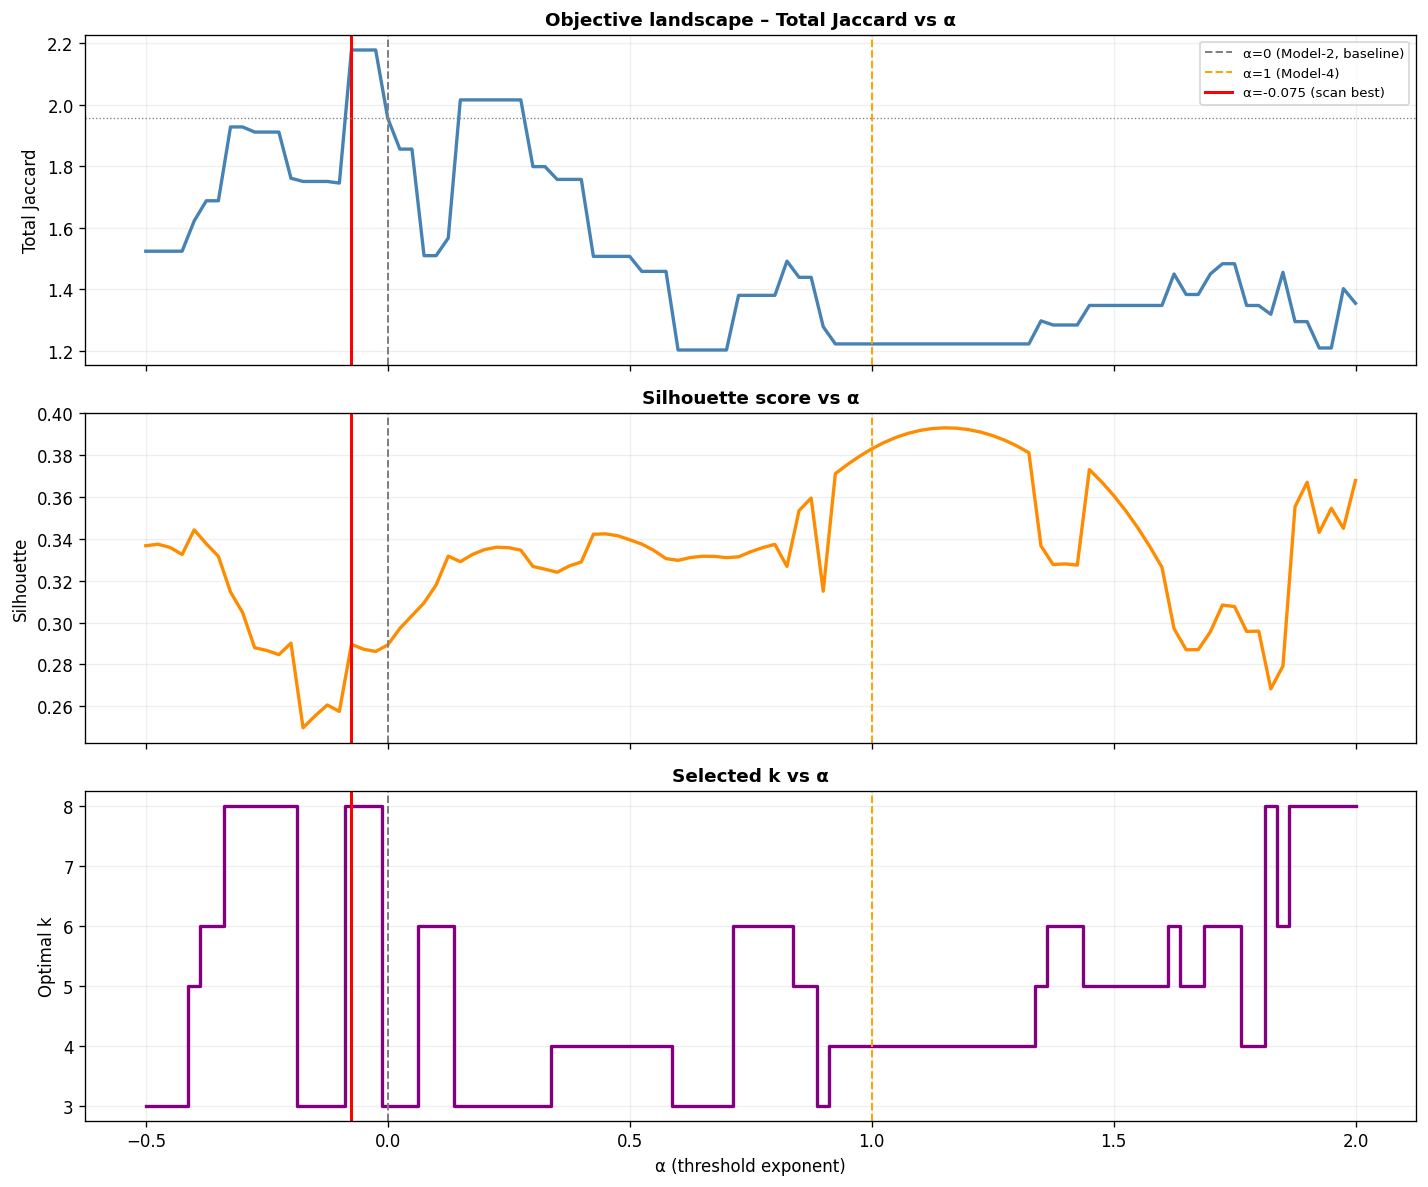

Saved → v11_alpha_landscape.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax = axes[0]
ax.plot(alphas, jaccards, color='steelblue', lw=2)
ax.axvline(0.0,       color='gray',   lw=1.2, ls='--', label='α=0 (Model-2, baseline)')
ax.axvline(1.0,       color='orange', lw=1.2, ls='--', label='α=1 (Model-4)')
ax.axvline(best_alpha,color='red',    lw=1.8, ls='-',  label=f'α={best_alpha:.3f} (scan best)')
ax.axhline(score_base,color='gray',   lw=0.8, ls=':')
ax.set_ylabel('Total Jaccard', fontsize=10)
ax.set_title('Objective landscape – Total Jaccard vs α', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.plot(alphas, silhous, color='darkorange', lw=2)
ax.axvline(0.0,       color='gray',   lw=1.2, ls='--')
ax.axvline(1.0,       color='orange', lw=1.2, ls='--')
ax.axvline(best_alpha,color='red',    lw=1.8, ls='-')
ax.set_ylabel('Silhouette', fontsize=10)
ax.set_title('Silhouette score vs α', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.2)

ax = axes[2]
ax.step(alphas, ks, color='purple', lw=2, where='mid')
ax.axvline(0.0,       color='gray',   lw=1.2, ls='--')
ax.axvline(1.0,       color='orange', lw=1.2, ls='--')
ax.axvline(best_alpha,color='red',    lw=1.8, ls='-')
ax.set_ylabel('Optimal k', fontsize=10)
ax.set_xlabel('α (threshold exponent)', fontsize=10)
ax.set_title('Selected k vs α', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v11_alpha_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → v11_alpha_landscape.png')

## 4. Bayesian Optimization with Optuna

Refine the search around the best region found by the scan.

In [7]:
def objective(trial):
    alpha     = trial.suggest_float('alpha', -0.5, 2.0)
    vecs      = build_vectors(alpha=alpha)
    lbl, k, s = cluster_vectors(vecs)
    return jaccard_score(lbl)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Seed with known anchors so BO starts informed
for a in [0.0, 0.25, 0.5, 0.75, 1.0, best_alpha]:
    study.enqueue_trial({'alpha': a})

study.optimize(objective, n_trials=120, show_progress_bar=True)

best_trial = study.best_trial
bo_alpha   = best_trial.params['alpha']
bo_jaccard = best_trial.value

print(f'\nBayesian optimization result:')
print(f'  Best α       = {bo_alpha:.4f}')
print(f'  Jaccard      = {bo_jaccard:.3f}')
print(f'  vs baseline  = {bo_jaccard - score_base:+.3f}')

  0%|          | 0/120 [00:00<?, ?it/s]

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24


Bayesian optimization result:
  Best α       = -0.0065
  Jaccard      = 2.633
  vs baseline  = +0.677


WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24

## 5. Detailed Result at Best α

In [8]:
vecs_best      = build_vectors(alpha=bo_alpha)
lbl_best, k_best, s_best = cluster_vectors(vecs_best)

clusters_best = {}
for l in sorted(set(lbl_best)):
    clusters_best[l] = {r for r, lb in zip(recipes, lbl_best) if lb == l}

print(f'Optimal α={bo_alpha:.4f}  k={k_best}  silhouette={s_best:.4f}  Jaccard={bo_jaccard:.3f}')
print()
print('Cluster assignments:')
for l, recs in clusters_best.items():
    print(f'  C{l}: {sorted(recs)}')

print()
print('='*75)
print('Per-group Jaccard breakdown')
print('='*75)

# Compare baseline vs best
clusters_base = {}
for l in sorted(set(lbl_base)):
    clusters_base[l] = {r for r, lb in zip(recipes, lbl_base) if lb == l}

total_base, total_best = 0, 0
for ref_name, ref_set in REFERENCE.items():
    def best_j_for(clusters):
        best, bname, bshared = 0, None, set()
        for cn, cs in clusters.items():
            sh = ref_set & cs
            j  = len(sh) / len(ref_set | cs) if (ref_set | cs) else 0
            if j > best:
                best, bname, bshared = j, cn, sh
        return best, bname, bshared

    j_base, cn_base, sh_base = best_j_for(clusters_base)
    j_best, cn_best, sh_best = best_j_for(clusters_best)
    total_base += j_base
    total_best += j_best
    delta  = j_best - j_base
    marker = f'  +{delta:.3f} ↑' if delta > 0.001 else (f'  {delta:.3f} ↓' if delta < -0.001 else '  = (no change)')

    print(f'\n{ref_name:15s}  ref={sorted(ref_set)}')
    print(f'  Baseline α=0.00  C{cn_base}  J={j_base:.3f}  shared={sorted(sh_base)}')
    miss = ref_set - sh_base
    if miss: print(f'    missing: {sorted(miss)}')
    print(f'  Best     α={bo_alpha:.3f}  C{cn_best}  J={j_best:.3f}  shared={sorted(sh_best)}')
    miss2 = ref_set - sh_best
    if miss2: print(f'    missing: {sorted(miss2)}')
    print(f'  {marker}')

print(f'\n{"="*75}')
print(f'TOTAL  Baseline={total_base:.3f}  Best α={total_best:.3f}  gain={total_best-total_base:+.3f}')

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points


Optimal α=-0.0065  k=8  silhouette=0.3093  Jaccard=2.633

Cluster assignments:
  C0: ['185.294', '185.507P']
  C1: ['185.237H', '185.309P', '186.277P', '187.694P']
  C2: ['185.091', '185.382P', '187.507P', '187.657P', '187.894P', '188.412P']
  C3: ['187.800P', '187.916P']
  C4: ['185.675P', '186.190P']
  C5: ['185.028']
  C6: ['185.090P', '185.267', '185.471', '187.787P', '187.796P', '187.886P']
  C7: ['188.740P']

Per-group Jaccard breakdown

Karamell         ref=['185.237H', '186.277P', '187.800P', '187.916P', '188.740P']
  Baseline α=0.00  C1  J=0.714  shared=['185.237H', '186.277P', '187.800P', '187.916P', '188.740P']
  Best     α=-0.007  C3  J=0.400  shared=['187.800P', '187.916P']
    missing: ['185.237H', '186.277P', '188.740P']
    -0.314 ↓

Grün             ref=['185.090P', '185.091', '185.309P', '185.675P', '187.657P', '188.412P']
  Baseline α=0.00  C2  J=0.400  shared=['185.091', '185.675P', '187.657P', '188.412P']
    missing: ['185.090P', '185.309P']
  Best     α=-0.007  C

WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points


## 6. Optimization History

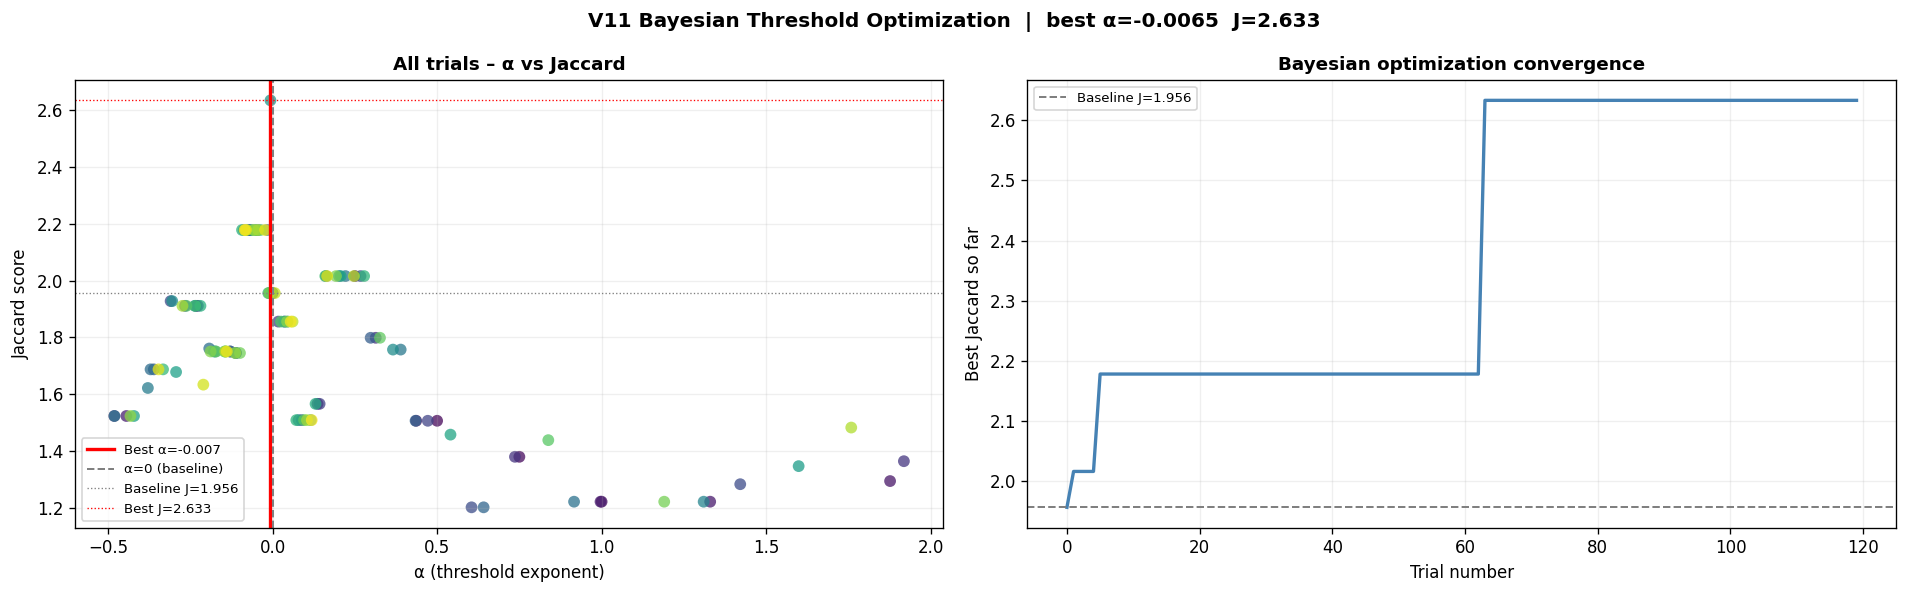

Saved → v11_bo_results.png


In [9]:
trial_alphas  = [t.params['alpha'] for t in study.trials]
trial_values  = [t.value          for t in study.trials]
running_best  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(trial_alphas, trial_values, c=range(len(trial_values)),
           cmap='viridis', s=50, alpha=0.75, edgecolors='none')
ax.axvline(bo_alpha,    color='red',  lw=2,   label=f'Best α={bo_alpha:.3f}')
ax.axvline(0.0,         color='gray', lw=1.2, ls='--', label='α=0 (baseline)')
ax.axhline(score_base,  color='gray', lw=0.8, ls=':',  label=f'Baseline J={score_base:.3f}')
ax.axhline(bo_jaccard,  color='red',  lw=0.8, ls=':',  label=f'Best J={bo_jaccard:.3f}')
ax.set_xlabel('α (threshold exponent)', fontsize=10)
ax.set_ylabel('Jaccard score', fontsize=10)
ax.set_title('All trials – α vs Jaccard', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.plot(running_best, color='steelblue', lw=2)
ax.axhline(score_base, color='gray', lw=1.2, ls='--', label=f'Baseline J={score_base:.3f}')
ax.set_xlabel('Trial number', fontsize=10)
ax.set_ylabel('Best Jaccard so far', fontsize=10)
ax.set_title('Bayesian optimization convergence', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.suptitle(f'V11 Bayesian Threshold Optimization  |  best α={bo_alpha:.4f}  J={bo_jaccard:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v11_bo_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → v11_bo_results.png')

## 7. Final Summary

In [10]:
print('='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'Model-2  α=0.00  (no threshold)   Jaccard = {score_base:.3f}')
print(f'Model-4  α=1.00  (full threshold)  Jaccard = {score_m4:.3f}')
print(f'V11 BO   α={bo_alpha:.4f}              Jaccard = {bo_jaccard:.3f}  (gain {bo_jaccard-score_base:+.3f})')
print()
if bo_jaccard > score_base + 0.05:
    print('Conclusion: threshold tuning meaningfully improves cluster alignment.')
    print(f'Recommended: use α={bo_alpha:.3f} instead of α=0.')
elif bo_jaccard > score_base:
    print('Conclusion: marginal improvement only.')
    print('The OT1 Grandfamilien vocabulary is the binding constraint, not the threshold.')
    print(f'α=0 (Model-2) remains the practical recommendation.')
else:
    print('Conclusion: no improvement. α=0 (Model-2) is optimal.')

FINAL SUMMARY
Model-2  α=0.00  (no threshold)   Jaccard = 1.956
Model-4  α=1.00  (full threshold)  Jaccard = 1.223
V11 BO   α=-0.0065              Jaccard = 2.633  (gain +0.677)

Conclusion: threshold tuning meaningfully improves cluster alignment.
Recommended: use α=-0.007 instead of α=0.
